In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [8]:
import os
os.listdir('/kaggle/input')
os.listdir('/kaggle/input/datasets/aaditmunje/wine-dataset')


['wine_dataset.csv']

In [11]:
df = pd.read_csv('/kaggle/input/datasets/aaditmunje/wine-dataset/wine_dataset.csv')
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [12]:
print(df.columns)

Index(['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium',
       'total_phenols', 'flavanoids', 'nonflavanoid_phenols',
       'proanthocyanins', 'color_intensity', 'hue',
       'od280/od315_of_diluted_wines', 'proline', 'target'],
      dtype='object')


I am choosing the first 3 columns ir alcohol, maleic acid and ash
Here because we have 3 features we need to predict the target which is 0/1/2

In [15]:
X = df[['alcohol','malic_acid','ash']]
y = df[['target']]

In [20]:
# Train-test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [23]:
from sklearn.linear_model import LinearRegression
import numpy as np

model = LinearRegression()
model.fit(X_train, y_train)

print("Intercept:", np.round(model.intercept_, 4))
print("Coefficients:", np.round(model.coef_, 4))

Intercept: [4.5667]
Coefficients: [[-0.3048  0.3307 -0.1823]]


Here i used np.round as round() doesn’t work directly on arrays. 

In [25]:
#Predicting the dataset
y_pred = model.predict(X_test)

In [26]:
# Now we are evaluating using MSE

y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print('MSE :', round(mse, 4))
print('R²  :', round(r2, 4))

MSE : 0.3884
R²  : 0.3343


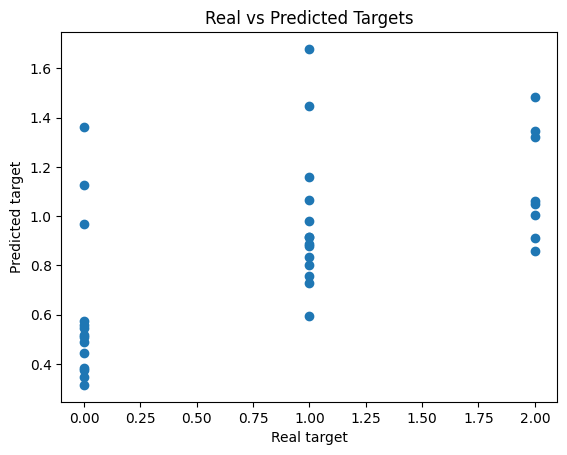

In [28]:
plt.scatter(y_test, y_pred)
plt.xlabel('Real target')
plt.ylabel('Predicted target')
plt.title('Real vs Predicted Targets')
plt.show()

If one column is a scalar multiple of the other we can detect this using 3 methods - 
1. Correlation - This tells us the relatibility of the columns with each other.

   
   corr = df.corr()
   print(corr)

   If the value comes out to be:
   approx 1 (Strong positive relationship)
   approx -1 (Strong negative relationship)
   approx 0 (No relationship)


3. Ratio Check

   If the ratio is constant it is a scalar multiple

   df['ratio'] = df['column1'] / df['column2']
   print(df['ratio'].head())


4. Scatter Plot

   If the 2 columns are scalar multiples then the scatter plots will be a straight line.


If one column is a scalar multiple of another, they show high correlation (~1 or -1), constant ratio, and linear relationship in scatter plot

   
   

   

In [29]:
corr = df['malic_acid'].corr(df['ash'])
print('Correlation between malic_acid and ash:', round(corr, 4))

Correlation between malic_acid and ash: 0.164


In [30]:
ratio = df['ash'] / df['malic_acid']

print('Min ratio :', round(ratio.min(), 4))
print('Max ratio :', round(ratio.max(), 4))
print('Mean ratio:', round(ratio.mean(), 4))
print('Std ratio :', round(ratio.std(), 4))

Min ratio : 0.3672
Max ratio : 3.3784
Mean ratio: 1.2193
Std ratio : 0.4986


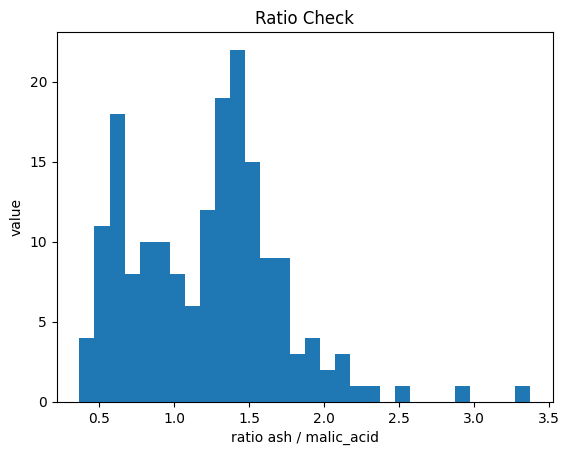

In [32]:
plt.hist(ratio, bins=30)
plt.xlabel('ratio ash / malic_acid')
plt.ylabel('value')
plt.title('Ratio Check')
plt.show()

If one column is a scalar multiple of the other (like malic_acid = 4* ash), then both columns carry the same information. This leads to perfect multicollinearity.

The coefficients become unstable now as the model is unable to understand where exactly to put the weight malic_acid / ash.


The model cannot distinguish the individual effect of each feature leading to errors

There will be error of greater magnitudes for even small changes in data ie small changes in data can cause large changes in weights.

In such cases the effectiveness of the model is reduced. Moreover it negatively affects the reliability and interpretability of the model.